In [177]:
import pandas as pd
import numpy as np
import seaborn as sns
import torch
import math
import datetime
import collections
from collections import OrderedDict
from torch import nn
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from torch.utils.data import DataLoader
import random
import matplotlib.pyplot as plt

In [2]:
# Read data
df = pd.read_csv('../data/main_timestamp.csv')

In [3]:
def preprocess(df):
    # first convert everything to int
    for col in df.select_dtypes(include=['number']):
        df[col] = df[col].apply(lambda x: round(x))

    # Get day, month, year, time_start, time_end
    df['day'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).day)
    df['month'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).month)
    df['year'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).year)
    df['hour_start'] = df['timestamp_start'].apply(lambda x: datetime.datetime.fromtimestamp(x).hour)
    df['workout_window'] = df['hour_start'].apply(lambda x: 'morning' if x < 11 else 'afternoon' if x < 17 else 'evening')

# Preprocess -- convert to int and add some features
preprocess(df)
df

,distance,duration,gender,heart_rate,sport,userId,timestamp_start,timestamp_end,calories,day,month,year,hour_start,workout_window
0,56,10810,male,143,bike,139383,1276037798,1276048608,3757,8,6,2010,15,afternoon
1,53,10798,male,138,bike,139383,1279234743,1279245541,3472,15,7,2010,15,afternoon
2,9,4838,male,159,run,212295,1274655206,1274660044,1054,23,5,2010,15,afternoon
3,6,2916,male,154,run,212295,1271032062,1271034978,620,11,4,2010,17,evening
4,26,6713,male,140,bike,139383,1288449864,1288456577,1530,30,10,2010,7,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166013,6,3688,male,160,bike,2934877,1444333665,1444337353,984,8,10,2015,12,afternoon
166014,3,1579,male,144,bike,2934877,1445364200,1445365779,358,20,10,2015,11,afternoon
166015,8,9931,male,156,bike,2934877,1445752071,1445762002,1623,24,10,2015,22,evening
166016,34,7072,male,146,bike,1731481,1440629051,1440636123,1581,26,8,2015,15,afternoon


In [5]:
# Encode user and sport
id_encoder = OrdinalEncoder()
sport_encoder = OrdinalEncoder()

df[['userId']] = id_encoder.fit_transform(df[['userId']])
df[['sport']] = sport_encoder.fit_transform(df[['sport']])

df = df.reset_index(drop=True)

df

,distance,duration,gender,heart_rate,sport,userId,timestamp_start,timestamp_end,calories,day,month,year,hour_start,workout_window
0,56,10810,male,143,3.0,43.0,1276037798,1276048608,3757,8,6,2010,15,afternoon
1,53,10798,male,138,3.0,43.0,1279234743,1279245541,3472,15,7,2010,15,afternoon
2,9,4838,male,159,26.0,59.0,1274655206,1274660044,1054,23,5,2010,15,afternoon
3,6,2916,male,154,26.0,59.0,1271032062,1271034978,620,11,4,2010,17,evening
4,26,6713,male,140,3.0,43.0,1288449864,1288456577,1530,30,10,2010,7,morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166013,6,3688,male,160,3.0,400.0,1444333665,1444337353,984,8,10,2015,12,afternoon
166014,3,1579,male,144,3.0,400.0,1445364200,1445365779,358,20,10,2015,11,afternoon
166015,8,9931,male,156,3.0,400.0,1445752071,1445762002,1623,24,10,2015,22,evening
166016,34,7072,male,146,3.0,254.0,1440629051,1440636123,1581,26,8,2015,15,afternoon


In [6]:
def train_test_split_chronological(df, test_size=0.2): 
    training_ids = []
    testing_ids = []

    training_size = 1 - test_size
    
    uids = df['userId'].unique()
    for userId in uids:
        subset = df[df['userId'] == userId]
        values = np.sort(df[df['userId'] == userId].timestamp_start.values)

        # if only one values, make it appear in both
        training_length = int(training_size * len(values))
        if training_length <= 1:
            trainset = values
            testset = values
        else:
            trainset = values[:training_length]
            testset = values[training_length:]
    
        training_ids.extend(subset[subset['timestamp_start'].isin(trainset)].index)
        testing_ids.extend(subset[subset['timestamp_start'].isin(testset)].index)

    train_df, test_df = df.iloc[training_ids], df.iloc[testing_ids]

    return train_df, test_df

In [7]:
class FitRecDataset():
    def __init__(self, dataframe):
        # Get an encoder
        self.df = dataframe

        self.df = self.df[['userId', 'sport']]
        
        self.features = torch.tensor(self.df.loc[:, ['userId']].values, dtype=int)
        self.labels = torch.tensor(self.df.loc[:, 'sport'].values, dtype=int)
            
    def __len__(self):
        return len(self.features)

    def get_encoder(self):
        return self.encoder

    def __getitem__(self, idx):
        """
        Return a row of data.
        """
        
        return self.features[idx], self.labels[idx]


In [8]:
# Split so that we train using past data, evaluate on the future
train_df, test_df = train_test_split_chronological(df, test_size=0.2)
train_df.shape, test_df.shape

((132430, 14), (33651, 14))

In [9]:
train_df['userId'].unique()

array([ 43.,  59.,  83., ..., 110., 618., 781.])

In [10]:
# Create the train and test set
trainset = FitRecDataset(train_df)
testset = FitRecDataset(test_df)

In [11]:
len(trainset), len(testset)

(132430, 33651)

In [12]:
# batch training and testing data
train_dataloader = DataLoader(trainset, batch_size=128, shuffle=True, drop_last=True)
test_dataloader = DataLoader(testset, batch_size=128, shuffle=True, drop_last=True)

In [13]:
for features, labels in train_dataloader:
    print(features)
    print(labels)

    break

tensor([[ 208],
        [ 991],
        [ 133],
        [ 684],
        [ 396],
        [ 300],
        [ 916],
        [ 484],
        [  36],
        [ 770],
        [ 419],
        [ 696],
        [ 585],
        [ 516],
        [ 143],
        [ 418],
        [ 506],
        [ 143],
        [ 361],
        [  20],
        [ 985],
        [  30],
        [ 203],
        [ 592],
        [  66],
        [ 164],
        [ 668],
        [ 840],
        [1002],
        [ 131],
        [ 806],
        [ 593],
        [ 602],
        [ 140],
        [   7],
        [ 774],
        [1051],
        [ 917],
        [ 724],
        [ 724],
        [ 736],
        [ 668],
        [ 153],
        [  74],
        [ 592],
        [ 883],
        [  29],
        [ 482],
        [ 152],
        [ 521],
        [ 132],
        [  86],
        [ 416],
        [ 390],
        [ 558],
        [ 211],
        [  31],
        [  69],
        [ 248],
        [  60],
        [1021],
        [ 412],
        

# User model

In [14]:
def get_per_sport_hr(subset):
    values = subset.groupby('sport', as_index=False).calories.mean().values
    per_sport_heart_rate = OrderedDict()
    
    for sport in df['sport'].unique():
        per_sport_heart_rate[sport] = 0
    
    for i in range(len(values)):
        sport, hr = values[i]
        per_sport_heart_rate[sport] = round(hr)
    
    return np.array(list(per_sport_heart_rate.values()))

In [15]:
def get_workout_frequency(subset):    
    # Workout frequency
    first_timestamp = subset.timestamp_start.min()
    last_timestamp = subset.timestamp_start.max()
    start = datetime.datetime.fromtimestamp(first_timestamp)
    end = datetime.datetime.fromtimestamp(last_timestamp)
    
    weeks = int((end - start).days / 7)

    if weeks == 0:
        return 1
    
    workout_per_week = len(subset) / weeks
    
    return round(workout_per_week)

def get_calories_per_week(subset):
     # Workout frequency
    first_timestamp = subset.timestamp_start.min()
    last_timestamp = subset.timestamp_start.max()
    start = datetime.datetime.fromtimestamp(first_timestamp)
    end = datetime.datetime.fromtimestamp(last_timestamp)
    
    weeks = int((end - start).days / 7)
    if weeks == 0:
        return 1
    
    workout_per_week = subset.calories.sum() / weeks
    
    return round(workout_per_week)

def get_duration_per_week(subset):
    # Workout frequency
    first_timestamp = subset.timestamp_start.min()
    last_timestamp = subset.timestamp_start.max()
    start = datetime.datetime.fromtimestamp(first_timestamp)
    end = datetime.datetime.fromtimestamp(last_timestamp)
    
    weeks = int((end - start).days / 7)
    if weeks == 0:
        return 1
    
    workout_per_week = subset.calories.sum() / weeks
    
    return round(workout_per_week)

In [28]:
def get_user_features(userId):
    subset = train_df[train_df['userId'] == userId].sort_values('timestamp_start')
    # How many workout per week
    workout_frequency = get_workout_frequency(subset)

    # Calories burn per week
    calories_per_week = get_calories_per_week(subset)

    # Workout duration per week
    duration_per_week = get_duration_per_week(subset)

    # Most common workout window -- either morning, afternoon or evening
    freq = collections.Counter(subset['workout_window'])
    common_workout_window = max(freq, key=freq.get)

    if common_workout_window == 'morning':
        common_workout_window = 1
    elif common_workout_window == 'afternoon':
        common_workout_window = 2
    else:
        common_workout_window = 1

    # workout heart rate per activity
    hr_per_activity = get_per_sport_hr(subset)
    
    result = torch.cat(
        (
            torch.tensor([
                workout_frequency, calories_per_week, common_workout_window, duration_per_week
            ]),
            torch.tensor(hr_per_activity)
        )
    )

    return  torch.tensor([
                workout_frequency, calories_per_week, common_workout_window, duration_per_week
            ])

In [29]:
# Pre build features for users
uids = train_df['userId'].unique()
user_features = {}

for userId in uids:
    user_features[userId] = get_user_features(userId)


In [32]:
class UserModel(nn.Module):
    def __init__(self, user_dim, output_dim, user_features):
        """
        A user is defined by
            userId
            gender
        """
        super().__init__()
        self.id_embedding = nn.Embedding(user_dim, output_dim)
        self.user_features = user_features
        self.projection = nn.Linear(64, 256)
        
    def forward(self, user_ids):
        # Transform into embedding dimension
        id_embeddings = self.id_embedding(user_ids)
        features = torch.stack(([user_features[int(i)] for i in user_ids]))

        # Concatenate features
        user_embedding = torch.cat((id_embeddings, features), dim=1)
        user_embedding = self.projection(user_embedding)
        return user_embedding

In [38]:
class RetrievalModel(nn.Module):
    def __init__(self, user_dim, embedding_dim, user_features, in_dim, out_dim):
        super().__init__()
        self.user_embedding = UserModel(user_dim, embedding_dim, user_features)
        self.norm = nn.BatchNorm1d(in_dim)
        self.fc1 = nn.Linear(in_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, out_dim)
        
        self.activation = nn.ReLU()

    def forward(self, user_ids):
        user_embds = self.user_embedding(user_ids)
        user_embds = self.norm(user_embds)
        x = self.activation(self.fc1(user_embds))
        x = self.activation(self.fc2(x))
        x = self.activation(self.fc3(x))
        x = self.fc4(x)

        return x
        

In [145]:
# Define model
user_dim = train_df['userId'].nunique()
embedding_dim = 60
model = RetrievalModel(user_dim, embedding_dim, user_features, in_dim=256, out_dim=len(sport_encoder.categories_[0]))

# Loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)


running_loss = 0
epochs = 11

per_epoch_losses = []
per_epoch_acc = []
per_epoch_f1 = []
# Train for 5 epochs
for epoch in range(1, epochs):
    model.train()
    epoch_loss = 0
    for i, (train_features, train_labels) in enumerate(train_dataloader):
        optimizer.zero_grad()
        
        outputs = model(train_features.squeeze())
    
        loss = loss_fn(outputs, train_labels)
        
        epoch_loss += loss.item()

        loss.backward()
        optimizer.step()

    correct = 0
    total = 0
    epoch_labels = []
    epoch_preds = []
    model.eval()
    for train_features, train_labels in train_dataloader:
        outputs = model(train_features.squeeze())
        preds = outputs.softmax(dim=1).argmax(dim=1)
        correct += (preds == train_labels).sum().item()
        total += len(preds)
        epoch_labels.extend(train_labels.detach().numpy())
        epoch_preds.extend(preds.detach().numpy())
    
    f_score = f1_score(epoch_labels, epoch_preds, average='macro')
    accuracy = correct / total
    
    # Record metrics per epoch
    per_epoch_losses.append(epoch_loss)
    per_epoch_acc.append(accuracy)
    per_epoch_f1.append(f_score)
    
    print(f'Epoch {epoch} -- Loss: {epoch_loss / len(train_dataloader):5} // Acc: {accuracy}')

Epoch 1 -- Loss: 0.8994425211815124 // Acc: 0.7279073984526112
Epoch 2 -- Loss: 0.6741852967835948 // Acc: 0.7694405826885881
Epoch 3 -- Loss: 0.6436657384758531 // Acc: 0.7693121373307543
Epoch 4 -- Loss: 0.6255049549864616 // Acc: 0.7775099734042553
Epoch 5 -- Loss: 0.6167785439719545 // Acc: 0.7541858075435203
Epoch 6 -- Loss: 0.6056682837539762 // Acc: 0.7865389264990329
Epoch 7 -- Loss: 0.5985446860239169 // Acc: 0.788745164410058
Epoch 8 -- Loss: 0.590865567672414 // Acc: 0.7825420091876208
Epoch 9 -- Loss: 0.5878029670890572 // Acc: 0.7895158365570599
Epoch 10 -- Loss: 0.5801351774822582 // Acc: 0.7883749395551257


In [161]:
# Testing
test_epoch_labels = []
test_epoch_preds = []
correct = 0
total = 0
model.eval()

for test_features, test_labels in test_dataloader:
    outputs = model(test_features.squeeze())
    preds = outputs.softmax(dim=1).argmax(dim=1)
    
    # Record metrics
    correct += (preds == test_labels).sum().item()
    total += len(preds)
    test_epoch_labels.extend(test_labels.detach().numpy())
    test_epoch_preds.extend(preds.detach().numpy())

test_f_score = f_score = f1_score(test_epoch_labels, test_epoch_preds, average='macro')
test_acc = correct / total

Text(0.5, 1.0, 'F1 vs Accuracy score')

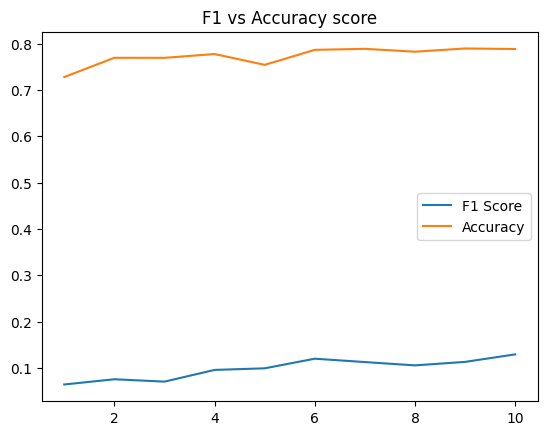

In [155]:
ax = sns.lineplot(x=np.arange(1, 11), y=per_epoch_f1, label='F1 Score')
ax = sns.lineplot(x=np.arange(1, 11), y=per_epoch_acc, label='Accuracy')
ax.set_title('F1 vs Accuracy score')

Text(0, 0.5, 'Loss')

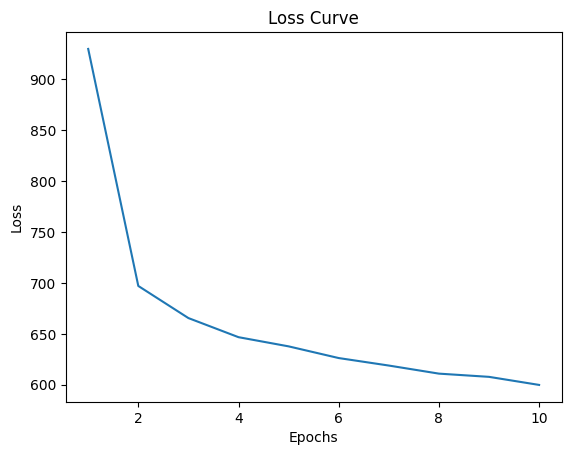

In [160]:
ax = sns.lineplot(x=np.arange(1, 11), y=per_epoch_losses)
ax.set_title('Loss Curve')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

<BarContainer object of 4 artists>

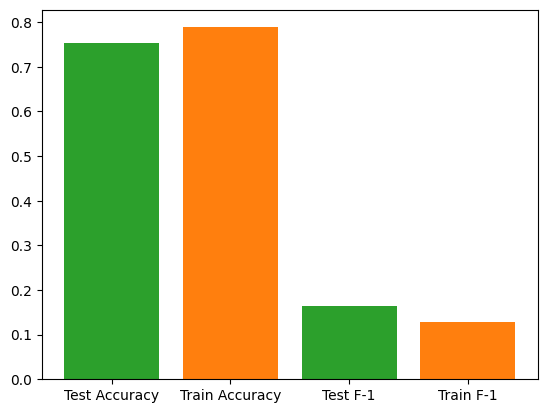

In [184]:
color = ['tab:green', 'tab:orange', 'tab:green', 'tab:orange']
fig, ax = plt.subplots()
ax.bar(['Test Accuracy', 'Train Accuracy', 'Test F-1', 'Train F-1'],
       [test_acc, per_epoch_acc[-1], test_f_score, per_epoch_f1[-1]],
       color=color)

In [192]:
precisions = []
recalls = []
for k in range(1, 7):
    precision = 0
    recall = 0
    for user in train_df['userId'].unique():
        # K relevant items for users
        n_sports = train_df[train_df['userId'] == user]['sport'].unique()

        # All relevant items
        k_sports = n_sports[:k]
        
    
        # Prediction for this user 
        scores = model(torch.tensor([int(user)])).softmax(dim=1).detach().squeeze()
    
        # Pick K most probable items
        indices = np.argpartition(scores, -k)[-k:].numpy()

    
        # Sum up to later divide
        precision  += len(np.intersect1d(k_sports, indices)) / k
        recall += len(np.intersect1d(n_sports, indices)) / len(n_sports)

        
    precision_at_k = precision / train_df['userId'].nunique()
    recall_at_k = recall / train_df['userId'].nunique()
    print(f"Precision @ {k}: {precision_at_k}")
    print(f"Recall @ {k}: {recall_at_k}")
    precisions.append(precision_at_k)
    recalls.append(recall_at_k)

# ax = sns.lineplot(x=precisions, y=recalls)
# ax.set_xlabel('Precision')
# ax.set_ylabel('Recall')
# ax.set_title('Precision vs Recall @ K -- Training')

Precision @ 1: 0.8001893939393939
Recall @ 1: 0.5616582491582486
Precision @ 2: 0.71875
Recall @ 2: 0.7684711700336695
Precision @ 3: 0.5782828282828306
Recall @ 3: 0.8365417568542565
Precision @ 4: 0.4812973484848485
Recall @ 4: 0.8777946879509374
Precision @ 5: 0.4115530303030255
Recall @ 5: 0.9036514700577194
Precision @ 6: 0.3574810606060624
Recall @ 6: 0.9221207611832605


Precision @ 1: 0.8049242424242424
Recall @ 1: 0.6636217081529581
Precision @ 2: 0.65625
Recall @ 2: 0.8592825577200573
Precision @ 3: 0.5009469696969686
Recall @ 3: 0.9071687860750356
Precision @ 4: 0.3951231060606061
Recall @ 4: 0.9296288780663774
Precision @ 5: 0.3274621212121166
Recall @ 5: 0.9478659361471855
Precision @ 6: 0.27935606060606194
Recall @ 6: 0.958938717532467


Text(0.5, 1.0, 'Precision vs Recall @ K')

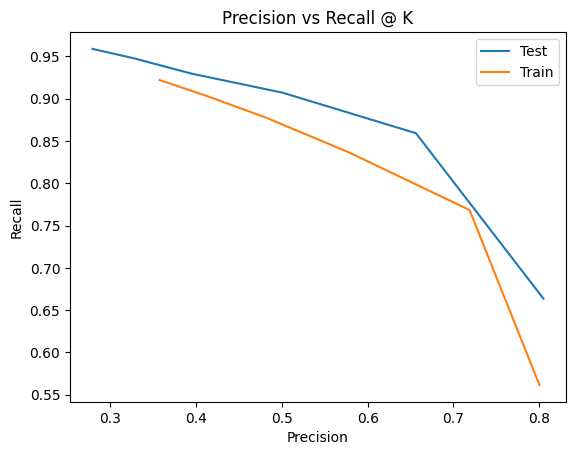

In [193]:
precision_test = []
recall_test = []
for k in range(1, 7):
    precision = 0
    recall = 0
    for user in test_df['userId'].unique():
        # K relevant items for users
        n_sports = test_df[test_df['userId'] == user]['sport'].unique()

        # All relevant items
        k_sports = n_sports[:k]
        
    
        # Prediction for this user 
        scores = model(torch.tensor([int(user)])).softmax(dim=1).detach().squeeze()
    
        # Pick K most probable items
        indices = np.argpartition(scores, -k)[-k:].numpy()

    
        # Sum up to later divide
        precision  += len(np.intersect1d(k_sports, indices)) / k
        recall += len(np.intersect1d(n_sports, indices)) / len(n_sports)

        
    precision_at_k = precision / test_df['userId'].nunique()
    recall_at_k = recall / test_df['userId'].nunique()
    print(f"Precision @ {k}: {precision_at_k}")
    print(f"Recall @ {k}: {recall_at_k}")
    precision_test.append(precision_at_k)
    recall_test.append(recall_at_k)

ax = sns.lineplot(x=precision_test, y=recall_test, label='Test')
sns.lineplot(x=precisions, y=recalls, label='Train')
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Precision vs Recall @ K')

In [194]:
precision_test, precisions

([0.8049242424242424,
  0.65625,
  0.5009469696969686,
  0.3951231060606061,
  0.3274621212121166,
  0.27935606060606194],
 [0.8001893939393939,
  0.71875,
  0.5782828282828306,
  0.4812973484848485,
  0.4115530303030255,
  0.3574810606060624])

In [195]:
recall_test, recalls

([0.6636217081529581,
  0.8592825577200573,
  0.9071687860750356,
  0.9296288780663774,
  0.9478659361471855,
  0.958938717532467],
 [0.5616582491582486,
  0.7684711700336695,
  0.8365417568542565,
  0.8777946879509374,
  0.9036514700577194,
  0.9221207611832605])

In [62]:
# Sample user inference
scores = model(torch.tensor([545])).softmax(dim=1).detach().squeeze()

indices = np.argpartition(scores, -5)[-5:]

print("Recommendation: ")
for sport in sport_encoder.inverse_transform(indices.reshape(-1, 1)):
    print('\t' + sport.item())

Recommendation: 
	core stability training
	walk
	bike (transport)
	bike
	run


In [63]:
# what is the user's history?
sport_encoder.inverse_transform(train_df[train_df['userId'] == 545].sport.unique().reshape(-1, 1))

array([['run'],
       ['kayaking'],
       ['bike']], dtype=object)